# Human–simulation correlations for any story

This notebook contains only configuration, function calls, and results. Reusable logic lives in `correlation_code/`; canonical geometry lives in `canonical_stimuli/`; reusable human measures live in `human_results/`; and new runs go to `outputs/experiments/`. Simulated trials never copy a human participant. Run Jupyter with `correlacion/` as the working directory.

In [1]:
from pathlib import Path
import sys

search_roots = [Path.cwd(), Path.cwd() / "correlacion", *Path.cwd().parents]
CORRELATION_DIR = next(path for path in search_roots if (path / "correlation_code").is_dir())
if str(CORRELATION_DIR) not in sys.path:
    sys.path.insert(0, str(CORRELATION_DIR))

from correlation_code import CorrelationConfig, available_stories, prepare_and_process
from correlation_code import compute_correlations, create_all_plots

## Available simulation stories

In [2]:
available_stories()

['Ahora_debería_reírme,_si_no_estuviera_muerto',
 'Axolotl',
 'Bienvenido_Bob',
 'Buenos_Aires',
 'Carta_a_una_señorita_en_París',
 'Carta_abierta',
 'Como_funcionan_los_bolsillos',
 'Educar_para_escalar_y_bucear',
 'El_almohadón_de_plumas',
 'El_golpe_de_gracia',
 'El_loco_cansino',
 'El_negro_de_París',
 'El_origen_de_las_especies',
 'Embarrar_la_magia',
 'La_canción_que_cantábamos_todos_los_días',
 'La_de_la_Obsesión_por_la_Patineta',
 'La_gallina_degollada',
 'La_lluvia_de_fuego',
 'La_máscara_de_la_Muerte_Roja',
 'La_noche_de_los_feos',
 'La_salud_de_los_enfermos',
 'Las_fotografías',
 'Rebeca',
 'Rubí_y_el_lago_danzante',
 'Sombras_sobre_vidrio_esmerilado_1',
 'Sombras_sobre_vidrio_esmerilado_2',
 'Una_rosa_para_Emilia',
 'Wakefield']

## Parameters

Use names from the list above. Set `SIMULATION_SUBJECTS = None` for every simulation in the story, or provide any list of subject IDs. Canonical geometry and human measures are reused from their caches. A missing human baseline is generated once in `human_results/` and reused thereafter. Geometry modes: `"canonical"` is neutral; `"json_x_canonical_y"` tests JSON x with canonical vertical geometry; and `"original_compatibility"` reproduces the old participant-template geometry.

In [3]:
STORY = "Wakefield"
SIMULATION_SUBJECTS = [f"ob1-{i:03d}" for i in range(1, 19)] # None means all subjects for this story
MEASURES = ["FFD", "FPRT", "TFD", "SFD", "SPRT", "RRT"]
N_BINS = 10
# canonical, json_x_canonical_y, or original_compatibility
GEOMETRY_MODE = "canonical"  

config = CorrelationConfig(
    story=STORY,
    simulation_subjects=SIMULATION_SUBJECTS,
    measures=MEASURES,
    n_bins=N_BINS,
    geometry_mode=GEOMETRY_MODE,
    # human_measures_dir=Path("human_results/My_story/measures"),
)
config

CorrelationConfig(story='Wakefield', simulation_subjects=['ob1-001', 'ob1-002', 'ob1-003', 'ob1-004', 'ob1-005', 'ob1-006', 'ob1-007', 'ob1-008', 'ob1-009', 'ob1-010', 'ob1-011', 'ob1-012', 'ob1-013', 'ob1-014', 'ob1-015', 'ob1-016', 'ob1-017', 'ob1-018'], measures=['FFD', 'FPRT', 'TFD', 'SFD', 'SPRT', 'RRT'], n_bins=10, excluded_humans=['sub-020', 'sub-113', 'sub-029', 'sub-069', 'sub-031', 'sub-087', 'sub-054', 'sub-085', 'sub-077', 'sub-060', 'sub-097', 'sub-070', 'sub-053', 'sub-036', 'sub-065', 'sub-039', 'sub-111', 'sub-003', 'sub-013', 'sub-066', 'sub-091', 'sub-018', 'sub-052'], simulations_root=PosixPath('/home/lucy/Documents/facu/reading-et/model_output'), human_measures_dir=None, experiments_root=PosixPath('/home/lucy/Documents/facu/reading-et/correlacion/outputs/experiments'), canonical_stimuli_dir=PosixPath('/home/lucy/Documents/facu/reading-et/correlacion/canonical_stimuli'), human_results_root=PosixPath('/home/lucy/Documents/facu/reading-et/correlacion/human_results'), s

## Process simulations through the original eye-tracking pipeline

In [4]:
run = prepare_and_process(config)
run.summary()

Assigning fixations to words...


Processing items in parallel:   0%|          | 0/1 [00:00<?, ?it/s]

----------------
Antes
      subj  screen  line  word_pos  trial_fix  screen_fix  duration     x
0  ob1-016       1     0         0        3.0         3.0     425.0  21.0
1  ob1-016       1     0         1        2.0         2.0     275.0  28.0
2  ob1-016       1     0         1        4.0         4.0     325.0  28.0
3  ob1-016       1     0         1        5.0         5.0     425.0  28.0
4  ob1-016       1     0         2        1.0         1.0     325.0  70.0
Después
      subj  screen  line  word_pos  trial_fix  screen_fix  duration     x
0  ob1-016       1     0         0        3.0         3.0     425.0  21.0
1  ob1-016       1     0         1        NaN         NaN       NaN   NaN
2  ob1-016       1     0         1        4.0         4.0     325.0  28.0
3  ob1-016       1     0         1        5.0         5.0     425.0  28.0
4  ob1-016       1     0         2        NaN         NaN       NaN   NaN
----------------
Antes
       subj  screen  line  word_pos  trial_fix  screen_fix

Processing items in parallel:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting eye-tracking measures from trials...


Processing items in parallel: 100%|██████████| 1/1 [00:54<00:00, 54.54s/it]


Analysing eye-tracking measures...


Traceback (most recent call last):
  File "/home/lucy/Documents/facu/reading-et/em_analysis.py", line 257, in <module>
    do_analysis(items_paths, words_freq_file, stats_file, save_path)
  File "/home/lucy/Documents/facu/reading-et/em_analysis.py", line 22, in do_analysis
    print_stats(et_measures, items_stats, save_path)
  File "/home/lucy/Documents/facu/reading-et/em_analysis.py", line 36, in print_stats
    processed_stats[item]['words'] = len(item_measures[~item_measures['excluded']]['word']) // n_subjs
                                     ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^~~~~~~~~
ZeroDivisionError: integer division or modulo by zero
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages

R[write to console]: 2: 

CalledProcessError: Command '['/home/lucy/Documents/facu/reading-et/tesis/bin/python', 'em_analysis.py', '--item', 'Wakefield', '--reprocess', '--participants', '/home/lucy/Documents/facu/reading-et/correlacion/outputs/experiments/2026_08_20_230832_733722_Wakefield/simulation_work/trials', '--wordsfix', '/home/lucy/Documents/facu/reading-et/correlacion/outputs/experiments/2026_08_20_230832_733722_Wakefield/simulation_work/words_fixations', '--measures', '/home/lucy/Documents/facu/reading-et/correlacion/outputs/experiments/2026_08_20_230832_733722_Wakefield/simulation_results/measures', '--output', '/home/lucy/Documents/facu/reading-et/correlacion/outputs/experiments/2026_08_20_230832_733722_Wakefield/simulation_results']' returned non-zero exit status 1.

## Validate word alignment and calculate correlations

In [ ]:
results = compute_correlations(run)
results.summary()

,story,human_subjects,simulation_subjects,retained_aligned_rows,measures,correlation_rows
0,El espejo,39,18,628,"FFD, FPRT, TFD, SFD, SPRT, RRT",4446


In [ ]:
results.correlations.sort_values("correlation", ascending=False).head(20)

,item,subject_1,subject_2,measure,correlation
2203,El espejo,sub-109,human_mean,TFD,0.721771
1462,El espejo,sub-109,human_mean,FPRT,0.697923
721,El espejo,sub-109,human_mean,FFD,0.681657
1500,El espejo,sub-001,human_mean,TFD,0.674556
2089,El espejo,sub-096,human_mean,TFD,0.666387
1348,El espejo,sub-096,human_mean,FPRT,0.658578
1956,El espejo,sub-079,human_mean,TFD,0.650409
2070,El espejo,sub-095,human_mean,TFD,0.646898
1329,El espejo,sub-095,human_mean,FPRT,0.639816
1766,El espejo,sub-044,human_mean,TFD,0.631729


## Save and display plots

PosixPath('/home/lucy/Documents/facu/reading-et/correlacion/outputs/experiments/2026_08_20_223059_963432_El_espejo/measures_correlation')

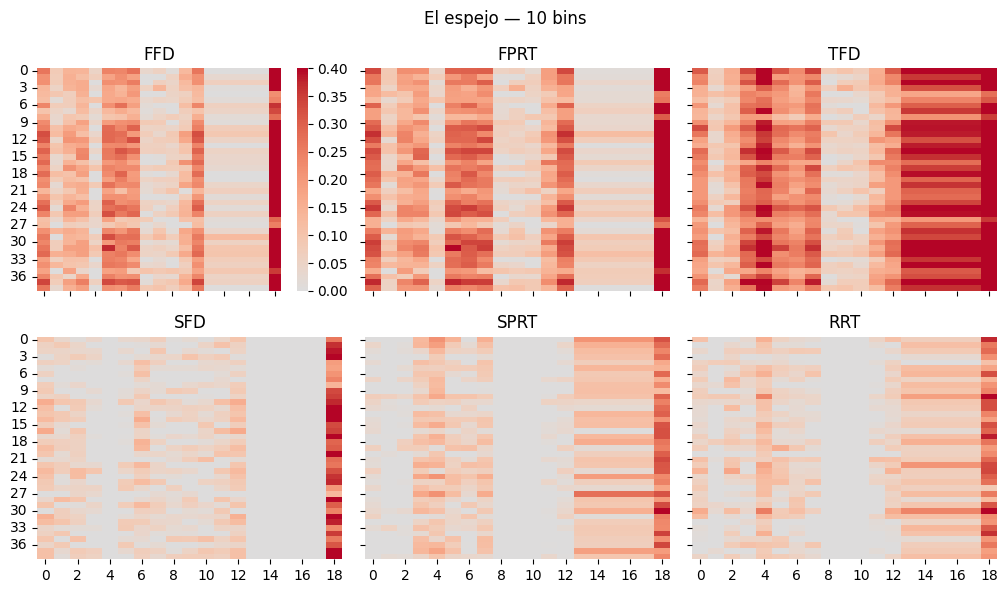

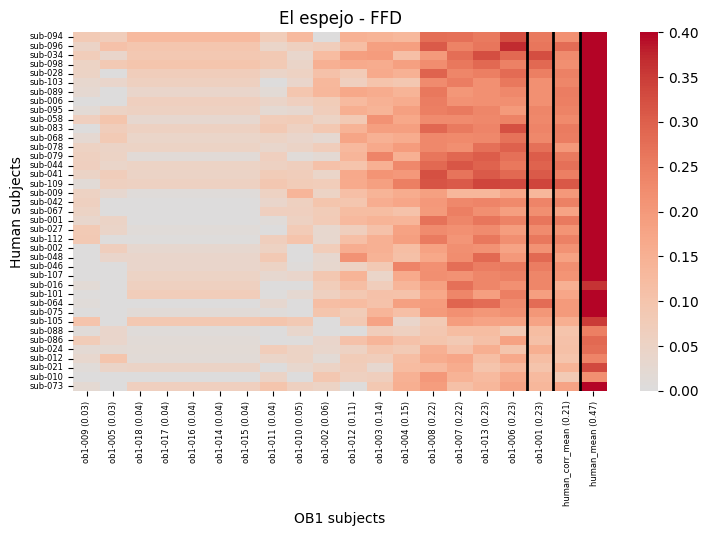

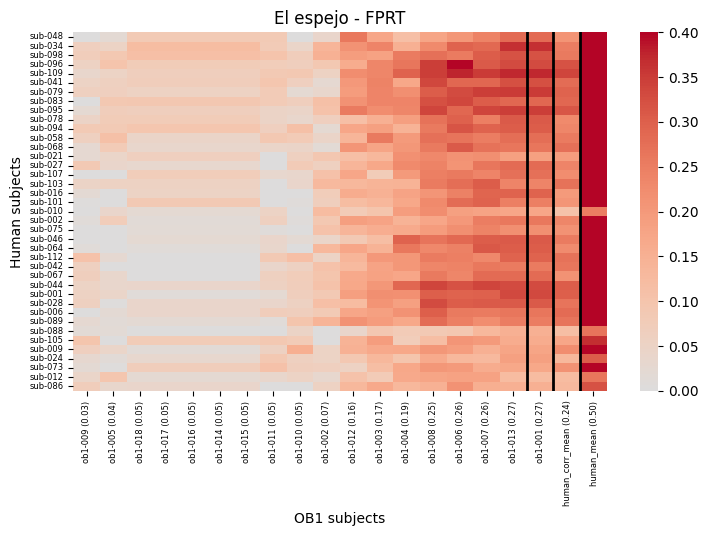

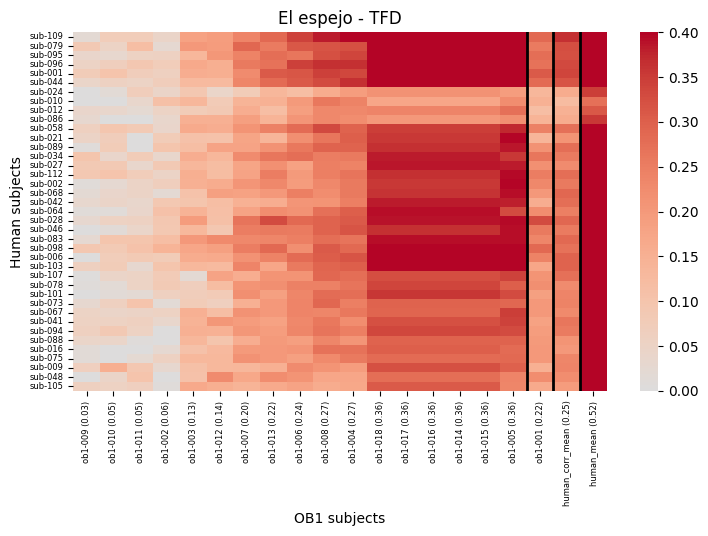

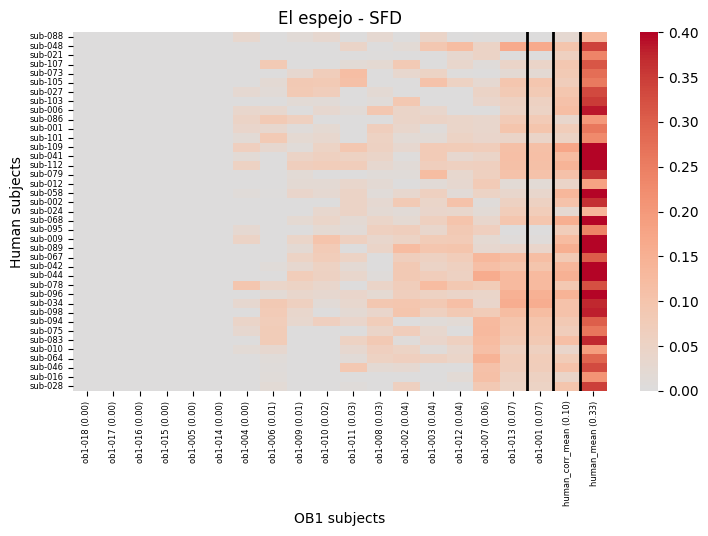

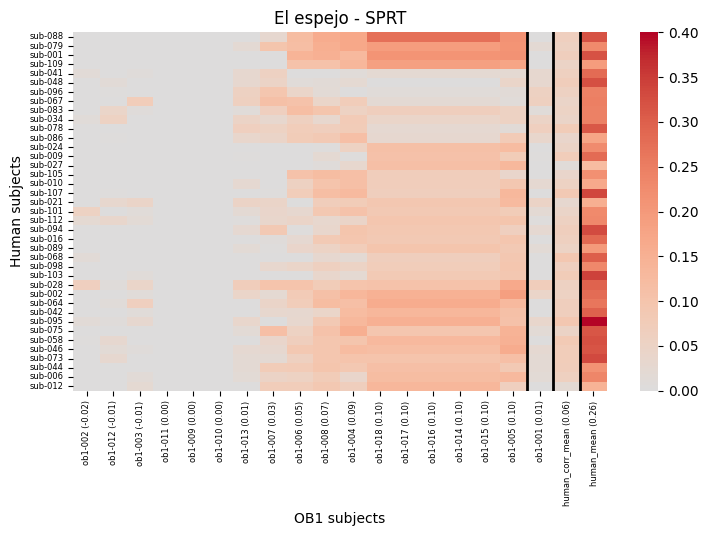

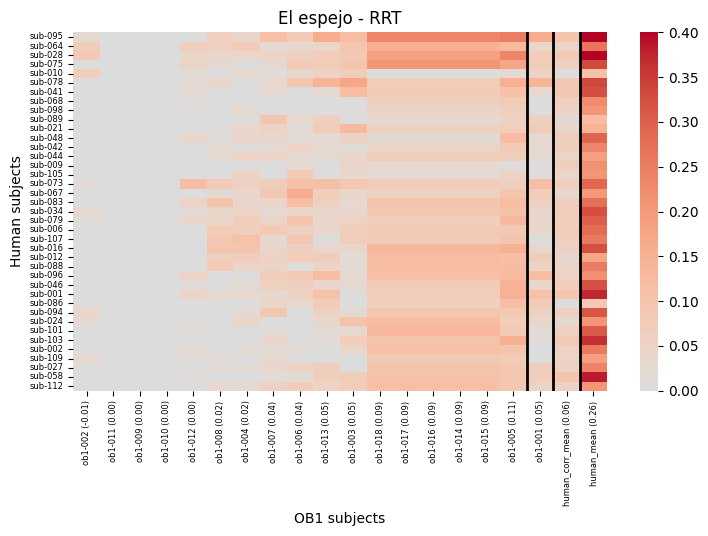

In [ ]:
figures = create_all_plots(results)
run.correlation_dir